Number of samples: 70000
Number of classes: 10
Image dimensions: 28 x 28 pixels (784 features)


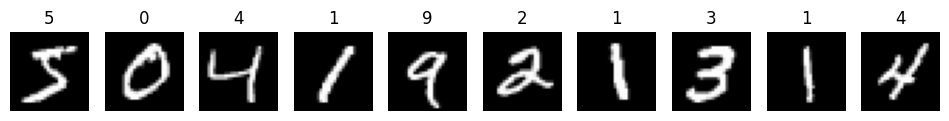

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_openml

# Load MNIST dataset
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist.data, mnist.target.astype(int)

# Dataset specifications
print(f'Number of samples: {X.shape[0]}')
print(f'Number of classes: {len(np.unique(y))}')
print(f'Image dimensions: 28 x 28 pixels ({X.shape[1]} features)')

# Normalize pixel values to range [0, 1]
X = X / 255.0

# Visualize 10 sample digits
fig, axes = plt.subplots(1, 10, figsize=(12, 2))
for i, ax in enumerate(axes):
  ax.imshow(X[i].reshape(28, 28), cmap='gray')
  ax.axis('off')
  ax.set_title(str(y[i]))
plt.show()


Components for 90% variance: 87
Components for 95% variance: 154
Components for 99% variance: 331


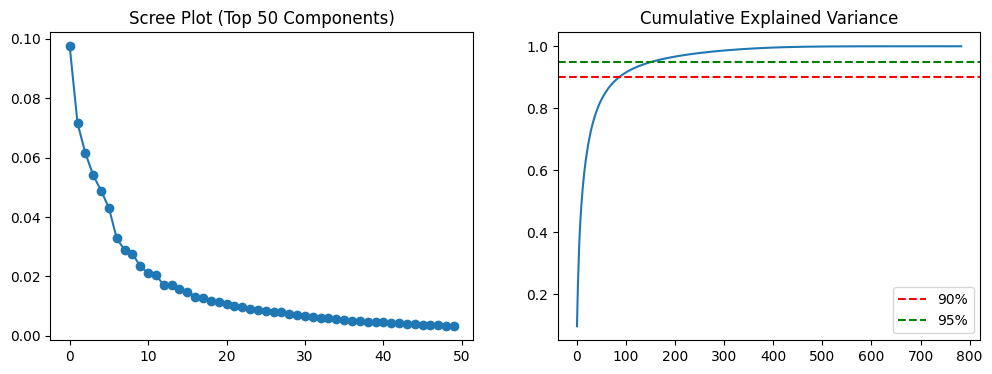

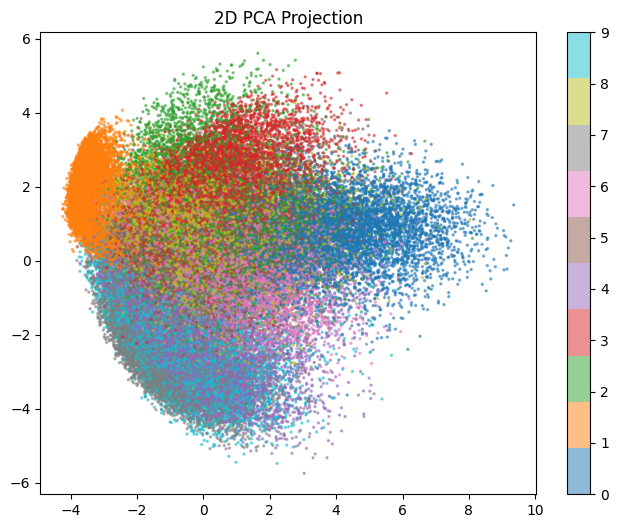

In [6]:
from sklearn.decomposition import PCA

# Fit PCA
pca_full = PCA()
pca_full.fit(X)

# Variance explained by each component & cumulative variance
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

# Components required for threshold variance
n_90 = np.argmax(cum_var >= 0.90) + 1
n_95 = np.argmax(cum_var >= 0.95) + 1
n_99 = np.argmax(cum_var >= 0.99) + 1

print(f'Components for 90% variance: {n_90}')
print(f'Components for 95% variance: {n_95}')
print(f'Components for 99% variance: {n_99}')

# Reduce dataset
pca_2d = PCA(n_components=2).fit_transform(X)
pca_50d = PCA(n_components=50).fit_transform(X)

# Plots
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(pca_full.explained_variance_ratio_[:50], marker='o')
plt.title('Scree Plot (Top 50 Components)')

plt.subplot(1, 2, 2)
plt.plot(cum_var)
plt.axhline(0.90, color='r', linestyle='--', label='90%')
plt.axhline(0.95, color='g', linestyle='--', label='95%')
plt.legend()
plt.title('Cumulative Explained Variance')
plt.show()

# 2D PCA projection scatter plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    pca_2d[:, 0], pca_2d[:, 1], c=y, cmap='tab10', alpha=0.5, s=2
)
plt.colorbar(scatter)
plt.title('2D PCA Projection')
plt.show()


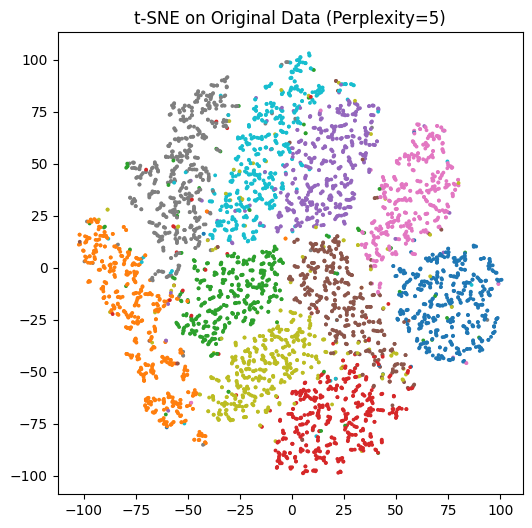

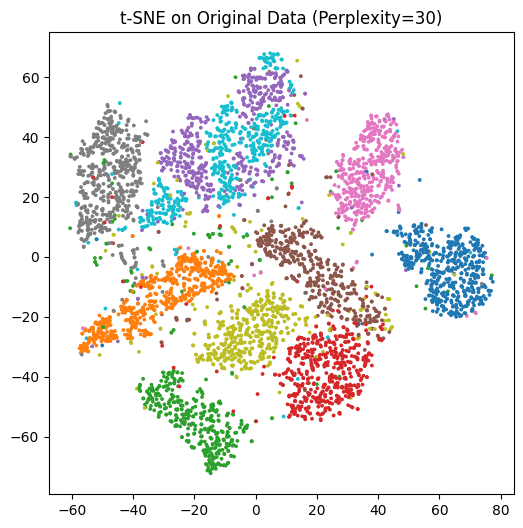

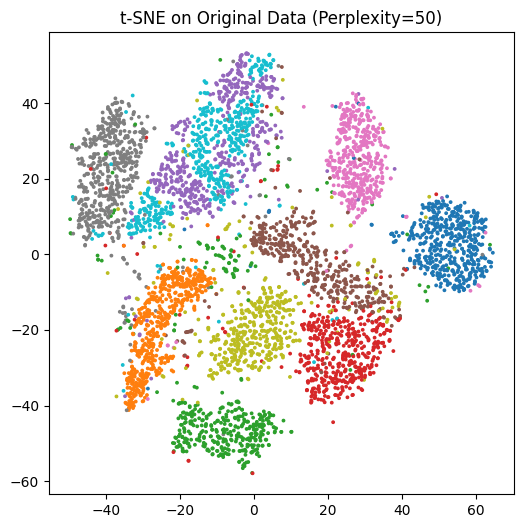

In [7]:
from sklearn.manifold import TSNE

# Subsample data for faster t-SNE computation (e.g., 5000 samples)
idx = np.random.permutation(len(X))[:5000]
X_sub, y_sub = X[idx], y[idx]
X_pca50_sub = pca_50d[idx]

# Experiment with perplexity
for perp in [5, 30, 50]:
  tsne_orig = TSNE(n_components=2, perplexity=perp, random_state=42).fit_transform(
      X_sub
  )
  plt.figure(figsize=(6, 6))
  plt.scatter(tsne_orig[:, 0], tsne_orig[:, 1], c=y_sub, cmap='tab10', s=3)
  plt.title(f't-SNE on Original Data (Perplexity={perp})')
  plt.show()


In [8]:
import time
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

# Split train/test subset for performance tracking
X_train, X_test = X[:10000], X[10000:12000]
y_train, y_test = y[:10000], y[10000:12000]

X_train_pca = pca_50d[:10000]
X_test_pca = pca_50d[10000:12000]

# Classifier on Original Data (784D)
clf_orig = KNeighborsClassifier(n_neighbors=3)
t0 = time.time()
clf_orig.fit(X_train, y_train)
train_time_orig = time.time() - t0
t0 = time.time()
pred_orig = clf_orig.predict(X_test)
pred_time_orig = time.time() - t0
acc_orig = accuracy_score(y_test, pred_orig)

# Classifier on PCA-reduced Data (50D)
clf_pca = KNeighborsClassifier(n_neighbors=3)
t0 = time.time()
clf_pca.fit(X_train_pca, y_train)
train_time_pca = time.time() - t0
t0 = time.time()
pred_pca = clf_pca.predict(X_test_pca)
pred_time_pca = time.time() - t0
acc_pca = accuracy_score(y_test, pred_pca)

print(f'Original 784D - Accuracy: {acc_orig:.4f}, Train Time: {train_time_orig:.2f}s, Pred Time: {pred_time_orig:.2f}s')
print(f'PCA 50D     - Accuracy: {acc_pca:.4f}, Train Time: {train_time_pca:.2f}s, Pred Time: {pred_time_pca:.2f}s')


Original 784D - Accuracy: 0.9545, Train Time: 0.02s, Pred Time: 0.85s
PCA 50D     - Accuracy: 0.9605, Train Time: 0.00s, Pred Time: 0.10s
